In [16]:
# sar_results columns
# hostname, interval, timestamp, CPU, %user, %nice, %system, %iowait, %steal, %idle

# flent_results keys
# Ping (ms) ICMP, Ping (ms) UDP BE, Ping (ms) UDP BK, Ping (ms) UDP EF, Ping (ms) avg, TCP download BE, TCP download BK, TCP download CS5, TCP download EF, TCP download avg, TCP download sum, TCP totals, TCP upload BE, TCP upload BK, TCP upload CS5, TCP upload EF, TCP upload avg, TCP upload sum

In [ ]:
import gzip
import json
import tabulate
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

project_dir = Path("C:\\sync\\projects\\vpn_benchmark")

In [62]:
def parse_benchmark_to_dataframe(root: Path) -> pd.DataFrame:
    with (root / "metadata.json").open("r") as f:
        meta_list = json.load(f)

    rows = []
    rows_flent = []

    for idx, meta in enumerate(meta_list):
        exp_dir = root / str(idx)

        row = {
            "vpn": meta.get("vpn"),
            "delay": meta.get("delay"),
            "jitter": meta.get("jitter"),
            "loss": meta.get("loss"),
            "cpu_freq": meta.get("cpu_freq"),
            "core_count": meta.get("core_count", 0)
        }

        # Process iperf3 results
        # ======================================================================

        iperf_file = exp_dir / "iperf.json"
        iperf_data = json.loads(iperf_file.read_text())
        bps = iperf_data["end"]["sum_received"]["bits_per_second"]
        row["throughput"] = int(bps / 1_000_000)

        # Process sar cpu results
        # ======================================================================

        sar_file = exp_dir / "cpu.csv"
        sar_df = pd.read_csv(sar_file, sep=None, engine='python')
        idle_values = pd.to_numeric(sar_df["%idle"], errors='coerce')
        row["cpu_mean"] = (100.0 - idle_values).mean()

        # Process flent results
        # ======================================================================

        flent_file = next(exp_dir.glob("*.flent.gz"))
        with gzip.open(flent_file, "rt") as f:
            raw = json.load(f).get("results", {})

        # Filter and map flent results
        keys = {"ping": "Ping (ms) avg", "tcp_down": "TCP download avg", "tcp_up": "TCP upload avg", "tcp_total": "TCP totals"}
        data = {k: [v for v in raw.get(v, []) if v is not None] for k, v in keys.items()}

        # Insert ping results into dataframe
        ping = pd.Series(data["ping"])
        row["jitter_measured"] = ping.diff().abs().mean()
        row["ping_p99"] = ping.quantile(0.95)
        row["ping_p50"] = ping.quantile(0.50)

        # Append rows
        # ======================================================================

        rows_flent.append({
            "tcp_down": pd.Series(data["tcp_down"]),
            "tcp_up": pd.Series(data["tcp_up"]),
            "tcp_total": pd.Series(data["tcp_total"])
        })

        rows.append(row)

    df = pd.DataFrame(rows)
    df_flent = pd.DataFrame(rows_flent)

    # Clean up
    df['loss'] = df['loss'].astype(str).str.replace('%', '', regex=False).astype(float)
    df['cpu_freq'] = df['cpu_freq'].astype(str).str.replace('GHz', '', regex=False).astype(float)
    df['delay'] = df['delay'].astype(str).str.replace('ms', '', regex=False).astype(int)
    df['jitter'] = df['jitter'].astype(str).str.replace('ms', '', regex=False).astype(int)

    # Enchance data
    df['efficiency'] = df['throughput'] / df['cpu_mean']
    df['jitter_delta'] = (df['jitter_measured'] - df['jitter']).clip(lower=0)

    return df, df_flent

In [ ]:
groups = ['vpn', 'delay', 'jitter', 'loss', 'cpu_freq', 'core_count']

df, df_flent = parse_benchmark_to_dataframe(project_dir / "results")
df_mean = df.groupby(groups).mean().reset_index()
df_var = df.groupby(groups).var().reset_index()

with open(project_dir / "process-results" / "output1.md", "w") as f:
    f.write(df_var.sort_values(by=["throughput"], ascending=False).to_markdown())

In [ ]:
selected_df = df[
    (df['core_count'] == 4) &
    True
].sort_values(by=["efficiency"], ascending=False)

with open(project_dir / "process-results" / "output1.md", "w") as f:
    f.write(selected_df.to_markdown())

summary = df.groupby(['vpn', 'core_count'])[['throughput', 'cpu_mean']].mean()
with open(project_dir / "process-results" / "output2.md", "w") as f:
    f.write(summary.to_markdown())

In [ ]:
palette={"none": "gray", "wireguard": "blue", "nebula": "orange", "openvpn": "green"}
edges = np.arange(0, df['jitter_delta'].max() + 1, 1)

g = sns.FacetGrid(df, row="vpn", hue="vpn",palette=palette, height=3, aspect=3.14, sharex=True)
g.map(sns.histplot, "jitter_delta", bins=edges)
g.set_axis_labels("VPN Jitter Amplification [miliseconds]", "Count")

for ax in g.axes.flatten():
    ax.set_xticks(np.arange(0, df['jitter_delta'].max() + 2, 1))
    #ax.set_yticks(np.arange(0, 15, 1))
    ax.grid(axis='y', alpha=0.3)
    ax.grid(axis='x', alpha=0.3)

plt.savefig(project_dir / "process-results" / "plot1.png")
plt.close()

In [ ]:
sdf = df[
    (df['jitter_delta'] > 0)
]

palette={"none": "gray", "wireguard": "blue", "nebula": "orange", "openvpn": "green"}
edges = np.arange(0, sdf['jitter_delta'].max() + 1, 1)

g = sns.FacetGrid(sdf, row="vpn", hue="vpn",palette=palette, height=3, aspect=3.14, sharex=True)
g.map(sns.histplot, "jitter_delta", bins=edges)
g.set_axis_labels("VPN Jitter Amplification [miliseconds]", "Count")

for ax in g.axes.flatten():
    ax.set_xticks(np.arange(0, sdf['jitter_delta'].max() + 2, 1))
    #ax.set_yticks(np.arange(0, 15, 1))
    ax.grid(axis='y', alpha=0.3)
    ax.grid(axis='x', alpha=0.3)

plt.savefig(project_dir / "process-results" / "plot2.png")
plt.close()

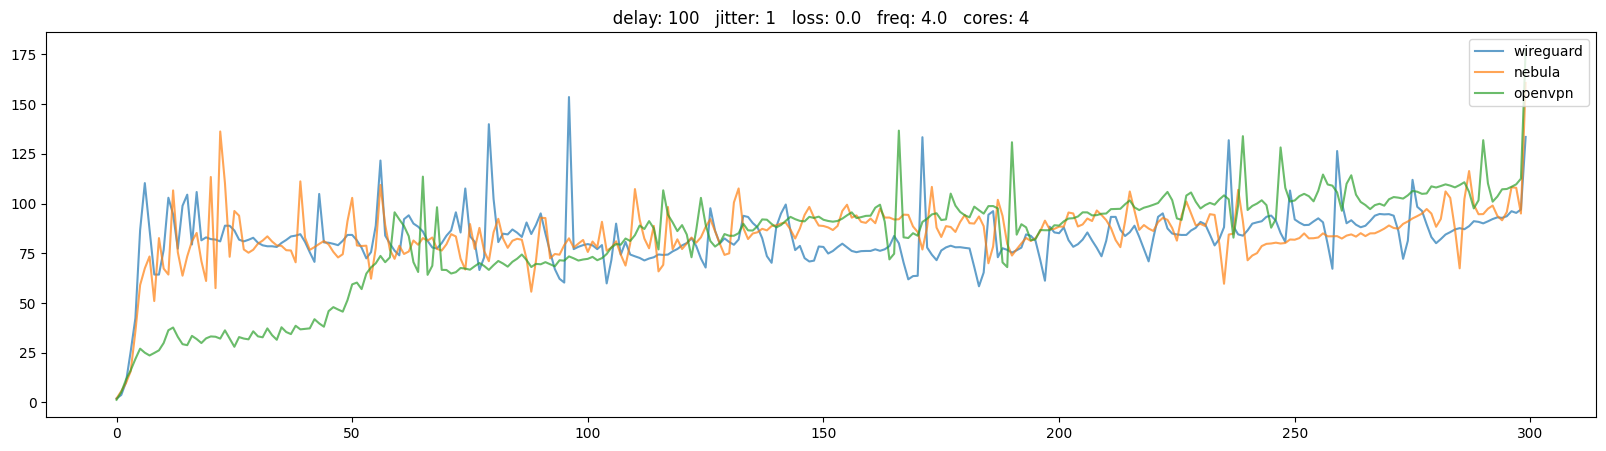

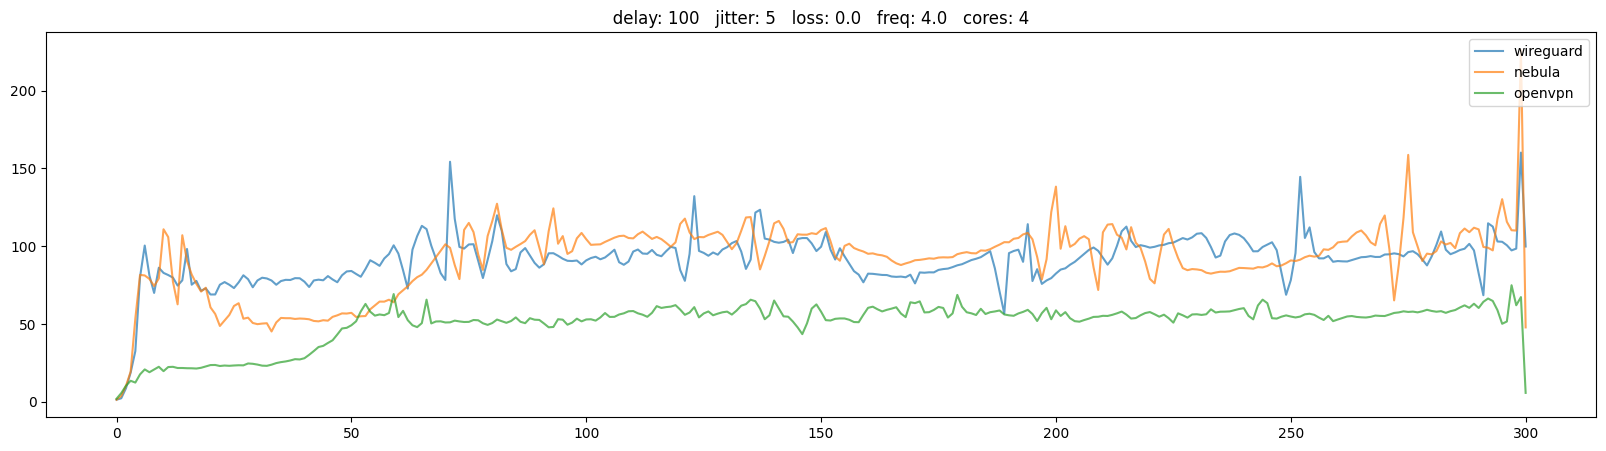

In [ ]:
sdf = df[
    (df['vpn'] != "none") &
    ((df['jitter'] == 1) | (df['jitter'] == 5))
]

grouped = sdf.groupby(['delay', 'jitter', 'loss', 'cpu_freq', 'core_count'])

for name, group in grouped:
    fig, ax = plt.subplots(figsize=(20, 5))

    for _, row in group.iterrows():
        ax.plot(row['tcp_total'], alpha=0.7, label=f"{row['vpn']}")
    ax.legend(loc='upper right')
    
    title = "   "
    for i, k in enumerate(("delay", "jitter", "loss", "freq", "cores")):
        title += f"{k}: {name[i]}   "
        
    plt.title(title)
    plt.show()